In [ ]:
# installing libraries:
!pip install scikit-learn pandas matplotlib numpy

In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)


In [ ]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
print("Shape:", X.shape)
print(df.head())

Shape: (150, 4)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [ ]:
# 1. imported the data
# 2. explored the dataset
# 3. scale the feature ( Transformation - Standard Scaler) :

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

In [ ]:
from sklearn.cluster import KMeans

for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(Xs)
    print(f"k={k}: WCSS={km.inertia_:.2f}")

k=1: WCSS=600.00
k=2: WCSS=222.36
k=3: WCSS=139.82
k=4: WCSS=114.09
k=5: WCSS=90.93
k=6: WCSS=81.54
k=7: WCSS=72.63


In [ ]:
from sklearn.cluster import KMeans


km = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = km.fit_predict(Xs)
# Centroids translated back to real-world units (cm)
centroids_cm = scaler.inverse_transform(km.cluster_centers_)
print(np.round(centroids_cm, 2))

[[5.8  2.67 4.37 1.41]
 [5.01 3.43 1.46 0.25]
 [6.78 3.1  5.51 1.97]]


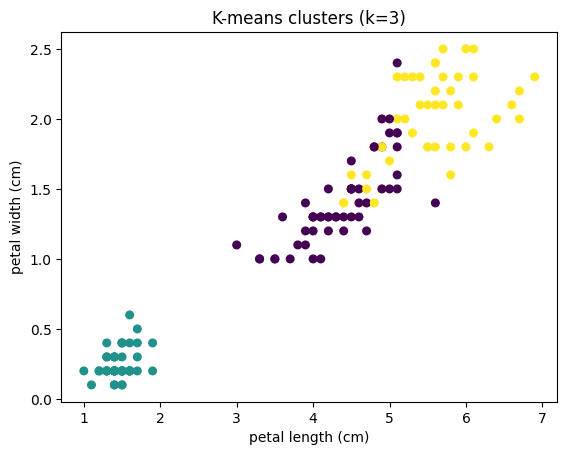

In [ ]:
# ready  for generating the visualisitiaons.

import matplotlib.pyplot as plt

plt.figure()
plt.scatter(X[:, 2], X[:, 3], c=clusters, cmap="viridis", s=30)
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.title("K-means clusters (k=3)")
plt.savefig("clusters.png", dpi=120, bbox_inches="tight")